# CIR and CME Detection from Phase Scintillation

This notebook applies a physically motivated detection pipeline to identify:

- Co-rotating Interaction Regions (CIRs)
- Transient CME-like disturbances

from DSN phase scintillation measurements.

---

## Overview of Method

The detection proceeds in three stages:

### 1. Remove elongation dependence

Phase scintillation strongly depends on solar elongation.  
We model the quiet baseline as a function of elongation and compute:

phase_ratio = observed / expected

This normalises the signal such that:

- quiet conditions → ~1
- disturbed conditions → >1

---

### 2. Detect CIR structures

CIRs are large-scale, long-duration structures.

We:
- smooth the phase_ratio over 12 hours
- apply hysteresis thresholds
- require duration > 24 hours

This isolates sustained enhancements in the solar wind.

---

### 3. Detect transient (CME-like) events

To isolate short-lived events:

- divide by CIR background:
  
  clean_signal = phase_ratio / phase_smooth

- apply a threshold to detect spikes
- filter by duration (0.25–24 hours)

These represent candidate CME-related disturbances.

---

## Output

This notebook produces:

- `phase_windows_detected_<year>.csv`
- `cir_regions_<year>.csv`
- `transient_events_<year>.csv`

---

## Interpretation

The pipeline separates contributions from:

- solar geometry (elongation)
- large-scale solar wind structure (CIRs)
- transient disturbances (CMEs)

This enables DSN Doppler data to be used as a diagnostic of heliospheric activity.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from src.io_utils import load_horizons_daily_sep
from src.detection_utils import (
    BaselineConfig,
    CIRConfig,
    TransientConfig,
    attach_daily_elongation_to_windows,
    build_phase_baseline_vs_elongation,
    detect_cir_regions,
    detect_transient_events,
)
from src.plot_utils import (
    plot_baseline_diagnostics,
    plot_cir_detection,
    plot_transient_detection,
    plot_pipeline_multi_panel,
)

from config.settings_2014 import *   # change year here
sav_file = True
debug = False


In [2]:
phase_csv = OUTPUT_DIR / f"phase_windows_{YEAR}.csv"

windows_df = pd.read_csv(
    phase_csv,
    parse_dates=["start", "end", "mid"]
)

horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)
windows_df = attach_daily_elongation_to_windows(windows_df, horizons_daily)
if debug:
    print("Loaded:", phase_csv)
    print("Rows:", len(windows_df))
    print("Missing elongation:", windows_df["elongation_deg"].isna().sum())

windows_df, binned = build_phase_baseline_vs_elongation(windows_df)
if debug:
    print("phase_ratio NaNs:", windows_df["phase_ratio"].isna().sum())

windows_df, cir_df = detect_cir_regions(windows_df)
if debug:
    print("Detected CIR regions:", len(cir_df))
    display(cir_df.head())

In [3]:
transient_cfg = TransientConfig(step_min=20)   # IMPORTANT

windows_df, events_df = detect_transient_events(
    windows_df,
    config=transient_cfg,
)
if debug:
    print("Detected transient events:", len(events_df))
    display(events_df.head())

In [4]:
if sav_file:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    windows_out = OUTPUT_DIR / f"phase_windows_detected_{YEAR}.csv"
    cir_out = OUTPUT_DIR / f"cir_regions_{YEAR}.csv"
    events_out = OUTPUT_DIR / f"transient_events_{YEAR}.csv"

    windows_df.to_csv(windows_out, index=False)
    cir_df.to_csv(cir_out, index=False)
    events_df.to_csv(events_out, index=False)

    print("Saved:", windows_out)
    print("Saved:", cir_out)
    print("Saved:", events_out)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/phase_windows_detected_2014.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/cir_regions_2014.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2014/transient_events_2014.csv


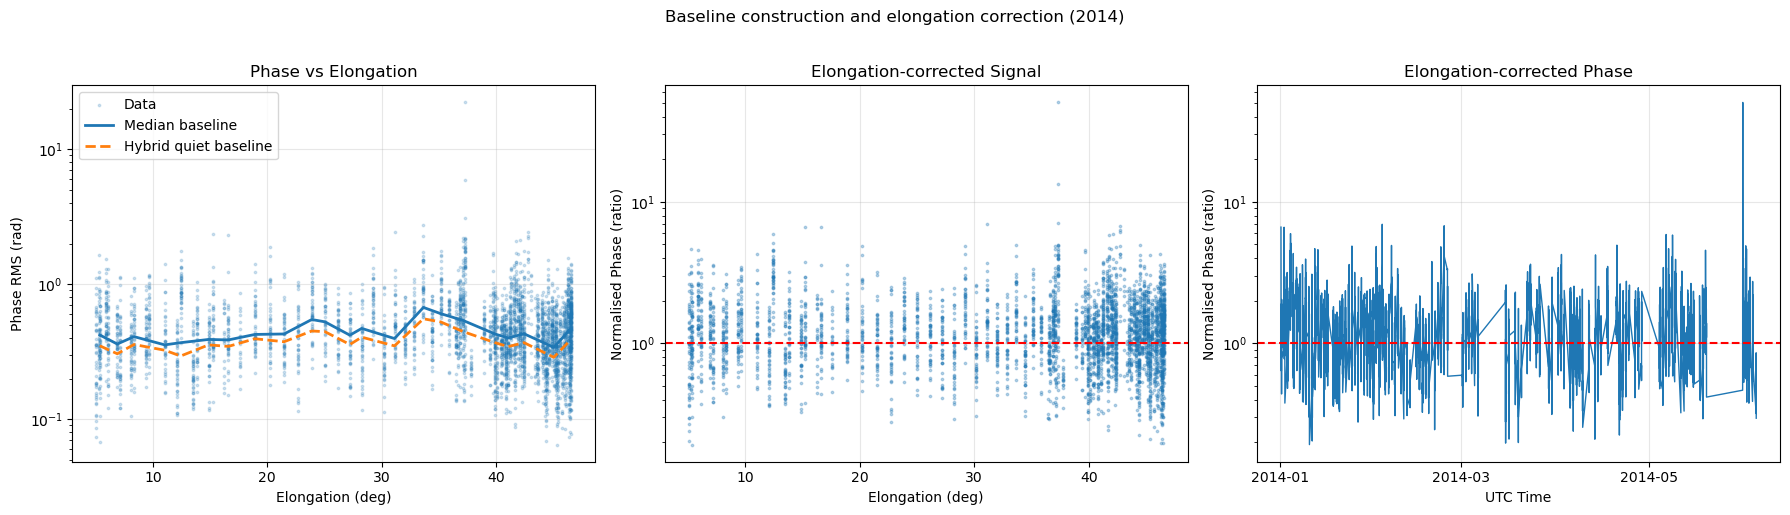

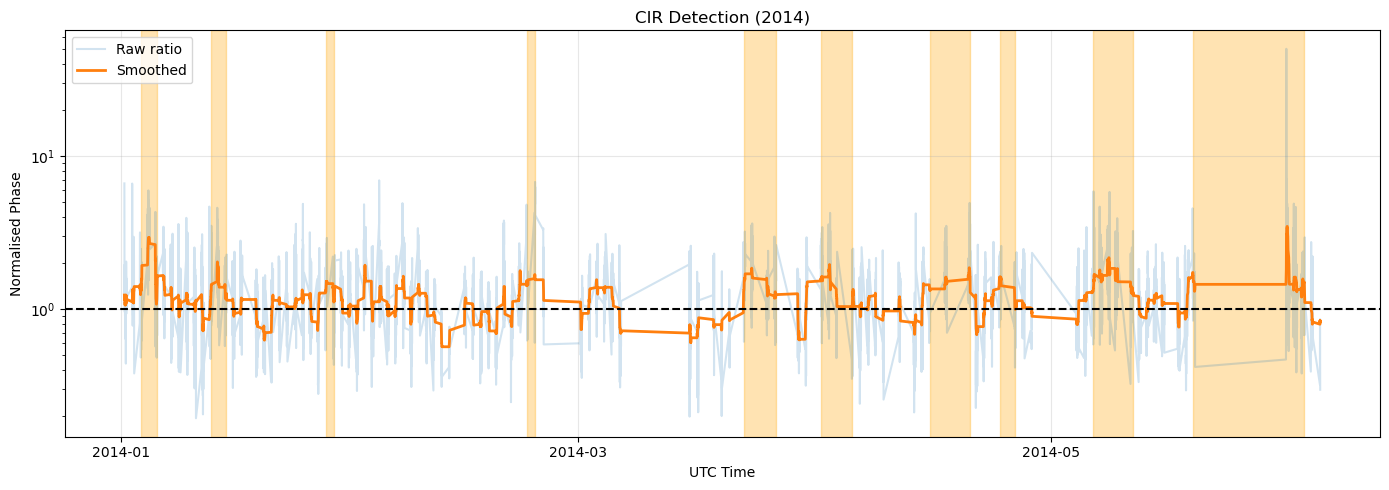

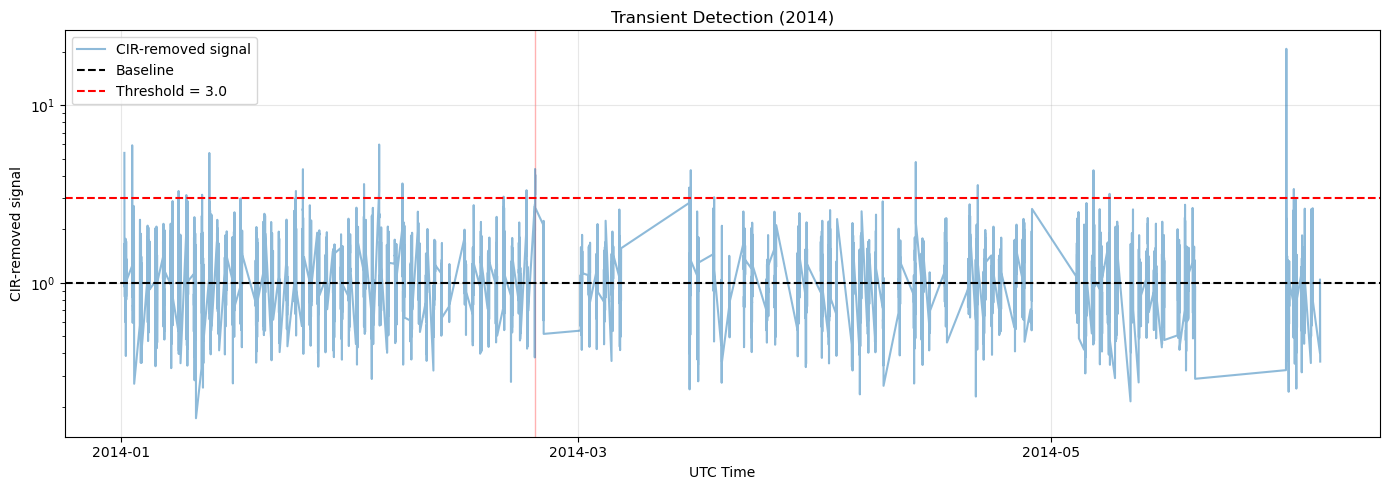

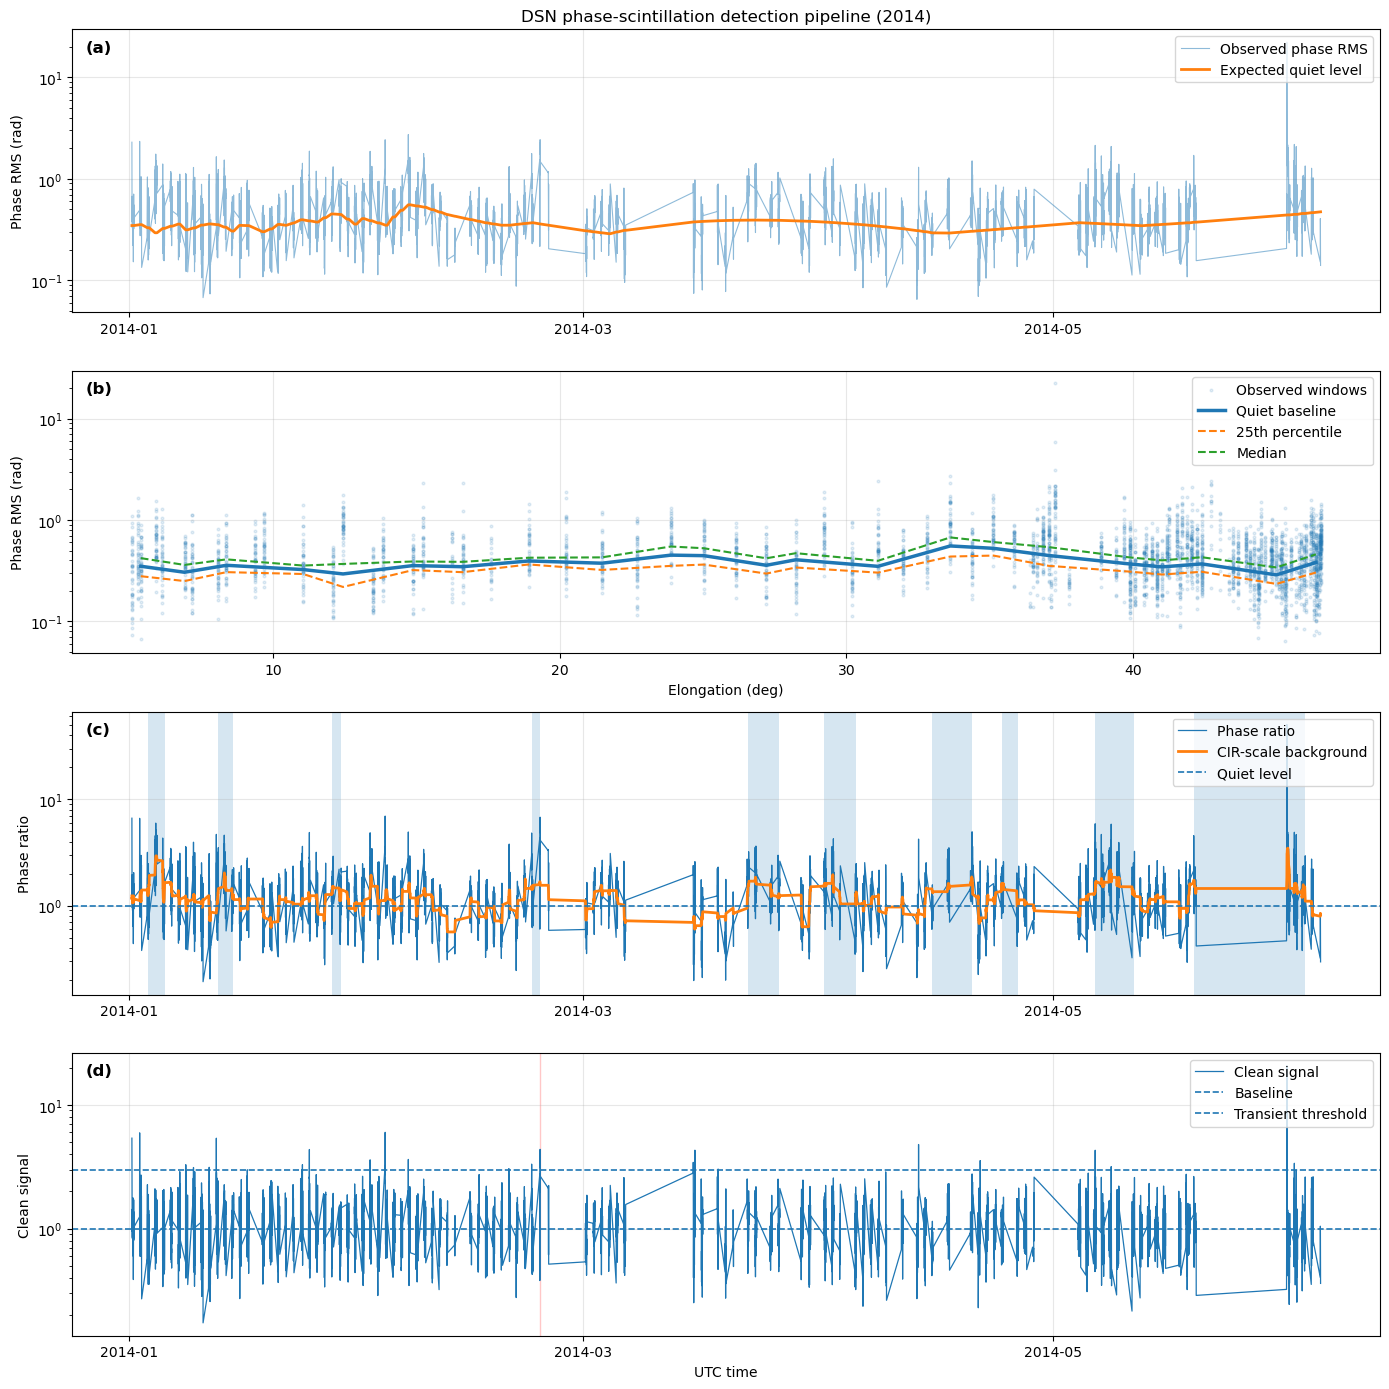

In [5]:
fig, axes = plot_baseline_diagnostics(
    w=windows_df.dropna(subset=["phase_ratio"]).copy(),
    binned=binned,
    year=YEAR,
)
plt.show()

fig, ax = plot_cir_detection(
    w=windows_df.dropna(subset=["phase_ratio", "phase_smooth"]).copy(),
    cir_df=cir_df,
    year=YEAR,
)
plt.show()

fig, ax = plot_transient_detection(
    w=windows_df.dropna(subset=["clean_signal"]).copy(),
    events_df=events_df,
    year=YEAR,
    threshold=3.0,
)
plt.show()

fig, axes = plot_pipeline_multi_panel(
    windows_df=windows_df,
    binned=binned,
    cir_df=cir_df,
    events_df=events_df,
    year=YEAR,
    transient_threshold=3.0,
)
plt.show()

## Threshold Calibration

This section is used to justify the empirical detection thresholds adopted in the pipeline.

The aim is not to optimise thresholds arbitrarily, but to demonstrate that the chosen values separate:

- quiet background conditions
- sustained large-scale enhancements (CIR-like structure)
- short-duration strong transients (CME-like structure)

The calibration is performed using the distributions of:

- `phase_ratio`, after removal of elongation dependence
- `phase_smooth`, representing the CIR-scale background
- `clean_signal`, after removal of the CIR-scale background

A suitable threshold should lie above the bulk of the quiet distribution while retaining sensitivity to clearly elevated events.

In [6]:
cal = windows_df.copy()

print("Total windows:", len(cal))

for col in ["phase_ratio", "phase_smooth", "clean_signal"]:
    if col in cal.columns:
        x = cal[col].dropna()
        print(f"\n{col}")
        print("  N      :", len(x))
        print("  min    :", x.min())
        print("  p25    :", x.quantile(0.25))
        print("  median :", x.median())
        print("  p75    :", x.quantile(0.75))
        print("  p90    :", x.quantile(0.90))
        print("  p95    :", x.quantile(0.95))
        print("  p99    :", x.quantile(0.99))
        print("  max    :", x.max())

Total windows: 4065

phase_ratio
  N      : 4065
  min    : 0.19265371736898326
  p25    : 0.815883199065049
  median : 1.1526028983455607
  p75    : 1.608816964935935
  p90    : 2.251491304369506
  p95    : 2.80117390481135
  p99    : 4.245050732639602
  max    : 50.42610673600105

phase_smooth
  N      : 4065
  min    : 0.5657884666778886
  p25    : 0.9514374824012805
  median : 1.1422301842591742
  p75    : 1.3702137692638052
  p90    : 1.602437966307287
  p95    : 1.7687066864609753
  p99    : 2.9270063124197785
  max    : 3.469663191853217

clean_signal
  N      : 4065
  min    : 0.17276347396306282
  p25    : 0.7498021865217818
  median : 1.0004119254071606
  p75    : 1.3255674261361237
  p90    : 1.7218778066821017
  p95    : 2.0672313841821945
  p99    : 2.879692743546891
  max    : 20.721715516872163


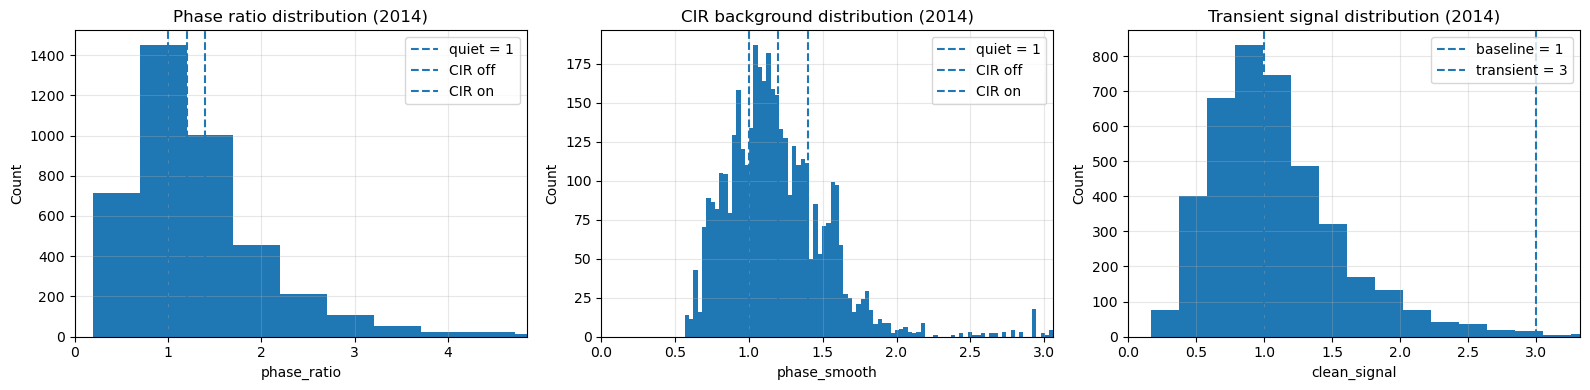

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# -------------------------
# phase_ratio
# -------------------------
x = cal["phase_ratio"].dropna()
axes[0].hist(x, bins=100)
axes[0].axvline(1.0, linestyle="--", label="quiet = 1")
axes[0].axvline(1.2, linestyle="--", label="CIR off")
axes[0].axvline(1.4, linestyle="--", label="CIR on")
axes[0].set_xlim(0, min(10, x.quantile(0.995)))
axes[0].set_xlabel("phase_ratio")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Phase ratio distribution ({YEAR})")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# -------------------------
# phase_smooth
# -------------------------
x = cal["phase_smooth"].dropna()
axes[1].hist(x, bins=100)
axes[1].axvline(1.0, linestyle="--", label="quiet = 1")
axes[1].axvline(1.2, linestyle="--", label="CIR off")
axes[1].axvline(1.4, linestyle="--", label="CIR on")
axes[1].set_xlim(0, min(10, x.quantile(0.995)))
axes[1].set_xlabel("phase_smooth")
axes[1].set_ylabel("Count")
axes[1].set_title(f"CIR background distribution ({YEAR})")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# -------------------------
# clean_signal
# -------------------------
x = cal["clean_signal"].dropna()
axes[2].hist(x, bins=100)
axes[2].axvline(1.0, linestyle="--", label="baseline = 1")
axes[2].axvline(3.0, linestyle="--", label="transient = 3")
axes[2].set_xlim(0, min(15, x.quantile(0.995)))
axes[2].set_xlabel("clean_signal")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Transient signal distribution ({YEAR})")
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [8]:
ratio = cal["phase_ratio"].dropna()
smooth = cal["phase_smooth"].dropna()
clean = cal["clean_signal"].dropna()

print("phase_ratio > 1.2 :", (ratio > 1.2).mean())
print("phase_ratio > 1.4 :", (ratio > 1.4).mean())
print("phase_smooth > 1.2:", (smooth > 1.2).mean())
print("phase_smooth > 1.4:", (smooth > 1.4).mean())
print("clean_signal > 3  :", (clean > 3.0).mean())

phase_ratio > 1.2 : 0.46494464944649444
phase_ratio > 1.4 : 0.35153751537515376
phase_smooth > 1.2: 0.4223862238622386
phase_smooth > 1.4: 0.22804428044280442
clean_signal > 3  : 0.008364083640836408


In [9]:
cir_on_grid = [1.2, 1.3, 1.4, 1.5, 1.6]
transient_grid = [2.0, 2.5, 3.0, 3.5, 4.0]

# simple CIR count sensitivity
cir_sensitivity = []

for th_on in cir_on_grid:
    temp = windows_df.copy().dropna(subset=["phase_ratio"]).sort_values("mid").copy()
    temp["tmp_smooth"] = (
        temp["phase_ratio"]
        .rolling(window=max(1, int(12 * 60 / 10)), center=True, min_periods=1)
        .median()
    )

    in_region = False
    regions = 0
    start = None

    for _, row in temp.iterrows():
        val = row["tmp_smooth"]

        if not in_region:
            if val > th_on:
                in_region = True
                start = row["mid"]
        else:
            if val <= 1.2:
                end = row["mid"]
                dur = (end - start).total_seconds() / 3600.0
                if dur >= 24:
                    regions += 1
                in_region = False
                start = None

    cir_sensitivity.append({"cir_on_threshold": th_on, "n_cir_regions": regions})

cir_sensitivity_df = pd.DataFrame(cir_sensitivity)
display(cir_sensitivity_df)

# simple transient sensitivity
trans_sensitivity = []

for th in transient_grid:
    temp = windows_df.copy().dropna(subset=["phase_ratio"]).sort_values("mid").copy()
    temp["tmp_smooth"] = (
        temp["phase_ratio"]
        .rolling(window=max(1, int(12 * 60 / 20)), center=True, min_periods=1)
        .median()
    )
    temp["tmp_clean"] = temp["phase_ratio"] / temp["tmp_smooth"]
    temp = temp.replace([np.inf, -np.inf], np.nan).dropna(subset=["tmp_clean"]).copy()

    temp["flag"] = temp["tmp_clean"] > th

    events = 0
    in_evt = False
    start = None

    for _, row in temp.iterrows():
        if row["flag"]:
            if not in_evt:
                in_evt = True
                start = row["mid"]
        else:
            if in_evt:
                end = row["mid"]
                dur = (end - start).total_seconds() / 3600.0
                if 0.25 < dur < 24:
                    events += 1
                in_evt = False
                start = None

    trans_sensitivity.append({"transient_threshold": th, "n_transients": events})

trans_sensitivity_df = pd.DataFrame(trans_sensitivity)
display(trans_sensitivity_df)

,cir_on_threshold,n_cir_regions
0,1.2,14
1,1.3,12
2,1.4,10
3,1.5,8
4,1.6,7


,transient_threshold,n_transients
0,2.0,38
1,2.5,18
2,3.0,8
3,3.5,3
4,4.0,1


## Calibration Interpretation

The `phase_ratio` and `phase_smooth` distributions are strongly peaked near unity, as expected for quiet conditions after elongation correction. The adopted CIR thresholds of 1.4 (entry) and 1.2 (exit) therefore lie above the bulk of the quiet distribution while still retaining sensitivity to sustained large-scale enhancements.

The `clean_signal` distribution is also concentrated near unity after removal of the CIR-scale background. Values above 3 occupy only the extreme upper tail, indicating that this threshold isolates unusually strong short-duration disturbances rather than ordinary fluctuations.

A simple threshold sensitivity test shows that lowering the transient threshold below 3 substantially increases the number of detected events, whereas raising it above 3 rapidly suppresses detections. The adopted value therefore represents a practical compromise between sensitivity and false positives.

The distributions show that both the elongation-corrected phase ratio and the CIR-corrected clean signal are strongly peaked near unity under quiet conditions. The adopted thresholds (1.4 for CIR detection and 3.0 for transient detection) lie above the bulk of these distributions and isolate statistically rare, physically significant deviations.

Although a significant fraction of individual windows exceed the CIR threshold, the requirement of sustained elevation (>24 hours) ensures that only coherent large-scale structures are identified as CIR regions.